In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy import stats

# 1B

In [1]:
x = [-.2, 0, .4, 1, 3, 10]

print(stats.norm.cdf(x))

[0.42074029 0.5        0.65542174 0.84134475 0.9986501  1.        ]


The above matches up with the z-table on wikipedia (approximately)

# 1C

In [2]:
z = [.0015, .025, 0.5, .841, 0.999999426696856]

print(stats.norm.ppf(z))

[-2.96773793 -1.95996398  0.          0.99857627  4.86464809]


Pretty close to integer sigmas save for the last, which is interesting as i pulled that value from Wikipedia for 5 sigma

# 1D

The minus signs just mean that the input is on the left/lower side of our distribution compared to the mean

# 2B

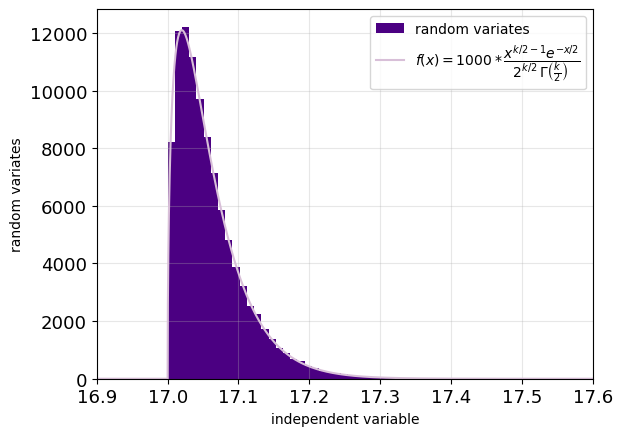

In [3]:
x = np.linspace(16.9, 20, 100000)
chipdf = scipy.stats.chi2.pdf(x, 3, loc = 17, scale = .02,) #chi squared pdf
chivar = scipy.stats.chi2.rvs(3, loc = 17, scale = .02, size = 100000) #chi squared random variates

fig, ax = plt.subplots()
plt.grid(True, alpha = 0.3)
ax.hist(chivar, 50, color = 'indigo', label = 'random variates')
ax.set_xlabel('independent variable')
ax.set_ylabel('random variates')
plt.tick_params(labelsize = 13)
plt.xlim(16.9, 17.6)
ax.plot(x, 1000*chipdf, color = 'thistle', label = r'$ f(x) = 1000 * \dfrac {x^{k/2-1}e^{-x/2}}{2^{k/2}\,\Gamma {\left({\frac {k}{2}}\right)}} $') 
# the multiplier for chipdf is to scale it up to the amount of samples we have; i couldn't figure a better way
ax.legend()
plt.show()

# 3A

I will imagine that i measured a value of 17.27

# 3B

Our question is "*what is the probability that the background produces a value of 17.27?*"

our integral is 

# $ \int_{17.27}^{\infty} \dfrac {x^{k/2-1}e^{-x/2}}{2^{k/2}\,\Gamma {\left({\frac {k}{2}}\right)}} dx $ 

# 3C

In [5]:

chicdf = 1 - scipy.stats.chi2.cdf(17.27, 3, loc = 17, scale = 0.02) # our integral, the 1 - makes it the complement
print(chicdf)

0.0036711317971558355


Let's convert this to sigma and back to get a probability.

# 3D

In [6]:
convert = scipy.stats.norm.ppf(chicdf)
print(convert)

-2.68090828570996


With a ~2.7 sigma i would hesitate to publish this.

Let's try some different measurements!

# 4

In [30]:
signals = [17.005, 17.05, 17.15, 17.3, 17.5]
probs = -1 * (scipy.stats.chi2.cdf(signals, 3, loc = 17, scale = 0.02) - 1)
sigmas = scipy.stats.norm.ppf(probs)
for n in range(len(signals)):
    print("signal: " + str(signals[n]) + "    ---->    probability: " + str(round(probs[n], 6)) + " ----> sigma value: " + str(round(sigmas[n],3)))

signal: 17.005    ---->    probability: 0.96914 ----> sigma value: 1.868
signal: 17.05    ---->    probability: 0.475291 ----> sigma value: -0.062
signal: 17.15    ---->    probability: 0.057558 ----> sigma value: -1.576
signal: 17.3    ---->    probability: 0.001817 ----> sigma value: -2.908
signal: 17.5    ---->    probability: 1.5e-05 ----> sigma value: -4.167


Interesting. Let's add it to the graph.

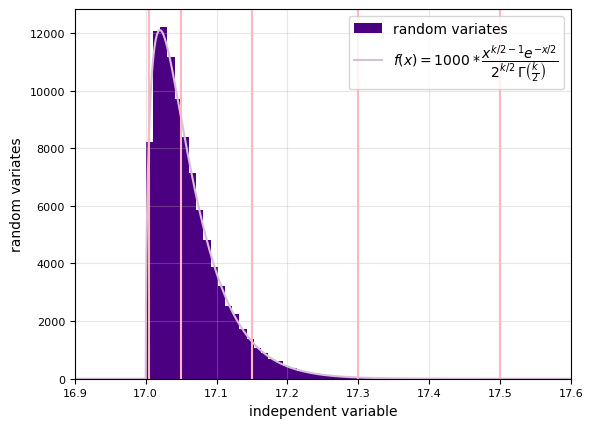

In [24]:
fig, ax = plt.subplots()
plt.grid(True, alpha = 0.3)
ax.hist(chivar, 50, color = 'indigo', label = 'random variates')
ax.set_xlabel('independent variable')
ax.set_ylabel('random variates')
plt.tick_params(labelsize = 8)
plt.xlim(16.9, 17.6)
ax.plot(x, 1000*chipdf, color = 'thistle', label = r'$ f(x) = 1000 * \dfrac {x^{k/2-1}e^{-x/2}}{2^{k/2}\,\Gamma {\left({\frac {k}{2}}\right)}} $') 
for n in range(len(signals)):
    ax.axvline(signals[n], color = 'lightpink')
plt.legend()
plt.show()

With some vertical lines at each of my chosen measurements. I'm publishing the 17.5 for sure!

This is an interesting distribution. 